# Machine Learning in Python - Project 

Due Friday, Apr 10th by 4 pm.

*Adele White, Aleksandra Pastore, Marta Gorecka*

## Setup

In [1]:
# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn modules
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

#modelling
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
# Load data  
df = pd.read_csv("unicef_malawi.csv")
df.head()

,HH1,HH2,LN,FS4,CB3,CB4,CB5A,CB5B,CB7,CB11,...,HC19,TN1,WS1,WS3,WS4,WS7,WS11,WS14,WS15,HW5
0,1.0,2.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,NO,PIPED WATER: PUBLIC TAP / STANDPIPE,ELSEWHERE,5.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,ELSEWHERE,YES,NO
1,1.0,3.0,1.0,1.0,5.0,YES,ECE,NaN,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITHOUT SLAB / OPEN PIT,IN OWN YARD / PLOT,NO,YES
2,1.0,4.0,2.0,2.0,16.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,6.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,YES
3,1.0,8.0,2.0,2.0,13.0,YES,PRIMARY,CLASS/GRADE 7,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,30.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO
4,1.0,10.0,2.0,2.0,14.0,YES,PRIMARY,CLASS/GRADE 6,YES,NO,...,NO,YES,TUBE WELL / BOREHOLE,ELSEWHERE,8.0,"NO, ALWAYS SUFFICIENT",PIT LATRINE: PIT LATRINE WITH SLAB,IN OWN YARD / PLOT,NO,NO


# Introduction

The mental health of young generations is a closely-monitored global concern, as early-life psychological conditions can have a major impact on health, socio-economic status, and overall life satisfaction [1]. These issues are particularly severe in low-income countries, where adverse living conditions can strongly affect mental health, especially at a young age [2,3]. Understanding the factors associated with childhood depression is essential for informing effective policy and intervention strategies for global organisations such as UNICEF. 

In this report, we develop a classification model to predict whether a child in Malawi is likely to experience symptoms of depression. The analysis is based on data from the UNICEF Multiple Indicator Cluster Survey (MICS), specifically a subset collected in Malawi between 2019 and 2020 [4]. This dataset was collected as part of a national household survey programme designed to monitor the wellbeing of children and women. It includes information from the child, maternal, and household questionnaires, capturing a broad range of features, such as demographic characteristics, education level, labour, discipline practices, maternal wellbeing, and household living conditions. The target variable is derived from responses to how frequently a child appears depressed, which is converted into a binary outcome of either **no reported depression symptoms** or presence of **any depressive symptoms**, regardless of frequency. 

The main aim of this study is to develop a classification model capable of predicting whether a child experiences symptoms of depression based on external factors. A secondary objective is to identify and analyse the most influential factors associated with the development of childhood depression, in order to improve understanding of the condition and support the development of effective policies.

The analysis begins with a thorough exploratory data analysis (EDA) and preprocessing stage, during which the dataset is examined, with particular focus on the substantial missing values that are identified to follow structured patterns based on survey logic. The data is then split into training and test sets to ensure subsequent unbiased model evaluation. Feature engineering techniques are used to reduce the dimensionality of the dataset and create more informative predictors, such as the composite severity scores for victimisation (`VT22_severity`) and physical punishment (`FCD2_severity`). An interpretable baseline logistic regression model is first implemented to establish a reference point for evaluating model performance, which is then compared to more complex and flexible machine learning methods, in order to account for nonlinear relationships present in the data. 

The final model selected is a Random Forest classifier. It was chosen because the EDA and baseline modelling both strongly suggested that no single feature clearly separates children based on depression incidence, but rather that depression is influenced by multiple interacting factors. The Random Forest model achieved the strongest overall performance, with a test ROC-AUC of approximately 0.64, which is an improvement over the baseline model result of around 0.62. This improvement is relatively small but it is still meaningful considering the complexity of the problem and the limitations of working with self-reported survey-based predictors.

The results highlight that a combination of child, caregiver, and household factors contribute to the outcome. In particular, household wealth, maternal education, physical punishment severity, victimisation-related variables, and caregiver wellbeing all appeared as important predictors in the final model [3]. This highlights the importance of considering both individual and environmental conditions when analysing childhood depression.

This report provides UNICEF with a detailed data-driven framework for identifying children at higher risk of developing depression and for understanding the broader societal and environmental conditions associated with this risk. These findings can assist in the creation of appropriate preventative interventions. In particular, the results of this work suggest that special attention needs to be dedicated to policies for reducing household deprivation, limiting children's exposure to violence and victimisation, and supporting the caregiver's overall wellbeing. A holistic approach to addressing these factors is likely to give the best results for reducing childhood depression incidence in low-income countries.

# Exploratory Data Analysis and Feature Engineering

### Initial Data Inspection

The project begins by performing an initial inspection of the data as part of the EDA to understand its structure, size, and variable types. This will also help identify data quality issues, such as missing values and inconsistent or inappropriate data types, which will inform subsequent preprocessing and feature engineering decisions.

In [3]:
# Inspect the dimensions of the dataset
print("Dataset shape:", df.shape)

# Display summary, non-null counts, and data types 
df.info()

Dataset shape: (13162, 87)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13162 entries, 0 to 13161
Data columns (total 87 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   HH1         13162 non-null  float64
 1   HH2         13162 non-null  float64
 2   LN          13162 non-null  float64
 3   FS4         13162 non-null  float64
 4   CB3         13059 non-null  float64
 5   CB4         13059 non-null  object 
 6   CB5A        12203 non-null  object 
 7   CB5B        11575 non-null  object 
 8   CB7         12203 non-null  object 
 9   CB11        13059 non-null  object 
 10  CL3         4159 non-null   float64
 11  CL13        11092 non-null  object 
 12  FCD2A       11264 non-null  object 
 13  FCD2B       11264 non-null  object 
 14  FCD2C       11264 non-null  object 
 15  FCD2D       11264 non-null  object 
 16  FCD2E       11264 non-null  object 
 17  FCD2F       11264 non-null  object 
 18  FCD2G       11264 non-null  object 
 19

In [4]:
# Total count of missing values
print(f"Total NaNs: {df.isnull().sum().sum()}")
# Number of rows with at least one missing value in a row
print(f"Number of rows with any NaN: {df.isnull().any(axis=1).sum()}")

# Observed "NO RESPONSE" as an answer in data
# Total count of 'NO RESPONSE'
print(f"Total \"NO RESPONSE\": {(df == "NO RESPONSE").sum().sum()}")
# Number of rows with at least one "NO RESPONSE"
print(f"Rows with any \"NO RESPONSE\": {df[df == "NO RESPONSE"].any(axis=1).sum()}")

Total NaNs: 71374
Number of rows with any NaN: 12458
Total "NO RESPONSE": 1293
Rows with any "NO RESPONSE": 1121


### Standardising Missing Values

From the first step of the EDA we identified that the dataset contains 13,162 observations and 87 variables, which suggests a large high-dimensional dataset suitable for subsequent machine learning analysis. The data types are a mix of binary/boolean answers, as well as numerical and categorical types, with the majority stored as object types. This makes sense for the nature of the data as responses are usually recorded as categorical values. These will require appropriate encoding before being used in modelling.
Another crucial observation is the presence of substantial missing data across many variables, for example the child labour hours variable CL3 only has 4159 non-null entries, which is a very low number compared to the size of the dataset. Features FCD5 (agreement with necessity of use of physical punishment) and HW5 (handwashing / availability of soap) show similar low numbers, while remaining columns are not as severely impacted by missing entries. Additionally, it has been observed that 12,458 rows have at least 1 missing value. This immediately suggests that simplifications such as use of `.dropna()` should be avoided, as they would risk losing about 95% of data.

The training/test data split was aimed to be performed as early in the process as possible to avoid any bias or data leakage. However, data cannot be split whilst containing missing values and the high severity of missingness would require careful analysis and, therefore, inevitably introducing bias. Hence, it was decided to globally, uniformly fill in the missing values to allow for an unbiased split of data first. Since one of the observed entries of the dataset were explicitly stated "NO RESPONSE" strings, the fill-in format matched this category for simplicity.

In [5]:
# Standardise missing values before training / test split by replacing NaN with "NO RESPONSE"
df = df.fillna("NO RESPONSE")

# Total count of "NO RESPONSE" values after fill
print(f"Total 'NO RESPONSE': {(df == 'NO RESPONSE').sum().sum()}")

# Number of rows with at least one "NO RESPONSE" after fill
print(f"Rows with at least one 'NO RESPONSE': {df[df == 'NO RESPONSE'].any(axis=1).shape[0]}")

Total 'NO RESPONSE': 72667
Rows with at least one 'NO RESPONSE': 13162


After the initial step of tackling missing entries, we print the number of rows with at least one "NO RESPONSE" in. This shows that each row contains at least one missing value. The goal is to retain non-null data while also preserving the structure of missingness, which would allow us to examine whether these missing responses are random or whether they follow systematic patterns of responders refusing to answer questions about specific topics. This is particularly important in survey datasets, such as this one, where missing values can reflect structured choices of skip patterns rather than random occasions.

### Train-Test Split (80/20)

To ensure we retain an appropriate dataset and avoid data leakage, the dataset should be split into training and test sets at an early stage of the analysis. We perform a widely used 80/20 split, with stratification based on the target variable "FCF26" to preserve the same proportion of the target class distribution of depression outcomes in both sets and reduce the chances of class imbalance in the classification model that can negatively affect model outcomes. At this stage, missing values have been tackled but not imputed and all subsequent preprocessing steps will be based on the training data and then applied to the test set to ensure that information from the test set does not influence model development.

In [6]:
# Separate features X and target variable y
X = df.drop(columns=["FCF26"])
y = df["FCF26"]

# Split data into training 80% and testing 20% sets
# Stratify on target variable to ensure distribution is preserved
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=8,
    stratify=y
)

# Combine features and target for easier inspection
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)

# Display shapes of the resulting datasets
print("Training set shape:", df_train.shape)
print("Test set shape:", df_test.shape)

Training set shape: (10529, 87)
Test set shape: (2633, 87)


The dataset has been successfully split into training and test sets, with approximately 80% of the data used for model development (10,529 observations) and 20% reserved for final evaluation (2,633 observations). Both sets retain the full set of 87 features. By stratifying the split on the target variable, the proportion of children with depressive symptoms is preserved, ensuring that model performance metrics are representative and accurate. The subsequent steps of the EDA will be conducted using the information from the training set only to avoid data leakage at this stage.

### Assessing Missing Values

We quantify the extent of missing data within the training set in order to guide preprocessing decisions of the most appropriate way to handle missing values. 

Percentage of rows with at least one missing value: 95.44%
Percentage of missing values in the target variable: 0.96%


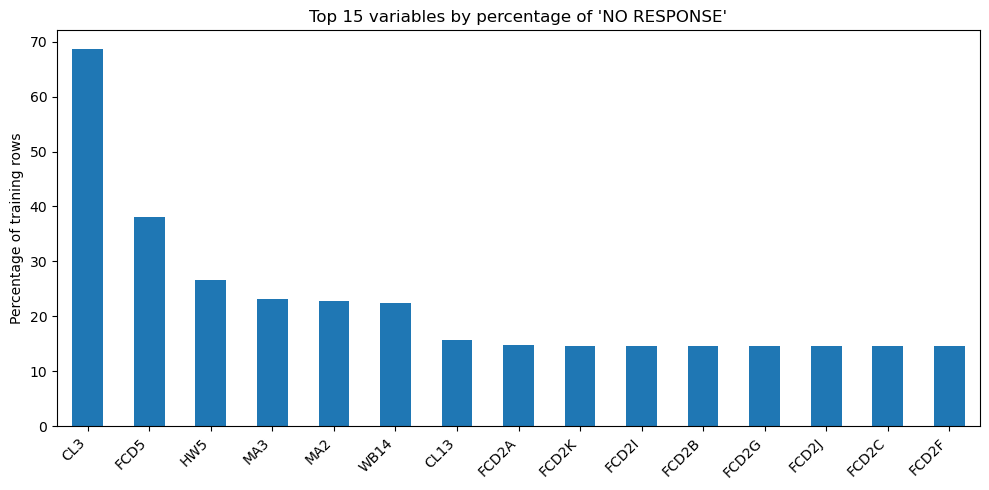

In [7]:
# Proportion of rows with at least one missing value
rows_with_no_response = (df_train == "NO RESPONSE").any(axis=1).sum()
total_rows = df_train.shape[0]
print(f"Percentage of rows with at least one missing value: {rows_with_no_response / total_rows:.2%}")

# Proportion of missing values in the target variable FCF26
target_missing = (df_train["FCF26"] == "NO RESPONSE").sum()
print(f"Percentage of missing values in the target variable: {target_missing / total_rows:.2%}")

# Plot the top 15 variables by percentage of missing values
missing_pct = (df_train == "NO RESPONSE").mean().sort_values(ascending=False) * 100

missing_pct.head(15).plot(kind="bar", figsize=(10, 5))
plt.ylabel("Percentage of training rows")
plt.title("Top 15 variables by percentage of 'NO RESPONSE'")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

This part shows that missingness affects the overwhelming majority of observations in the dataset, with 95.44% of rows containing at least one missing value. Thus, removing these rows completely would result in substantial data loss. 

In contrast, only 0.96% of observations have a missing value in the target variable "FCF26". This means these rows can be removed with minimal impact on sample size, allowing subsequent modelling to be based on known outcomes.

The proportion of missing values is very uneven across variables, which indicates patterns in survey responses. Therefore, missing data is likely explained by questionnaire structure or skip logic of respondents, and variable-specific preprocessing strategies are required to handle missing values.

In [8]:
# Remove rows with missing target values from both training and test sets
df_train = df_train[df_train["FCF26"] != "NO RESPONSE"]
df_test = df_test[df_test["FCF26"] != "NO RESPONSE"]

# Check updated shapes
print("Training set shape after removing missing target:", df_train.shape)
print("Test set shape after removing missing target:", df_test.shape)

Training set shape after removing missing target: (10428, 87)
Test set shape after removing missing target: (2608, 87)


### Groupwise Missing Data Handling

To further analyse the patterns behind missing data, the missing values are converted into binary indicators with 1 corresponding to "NO RESPONSE" and 0 corresponding to a valid response, and the relationships between variables are examined using correlation analysis.

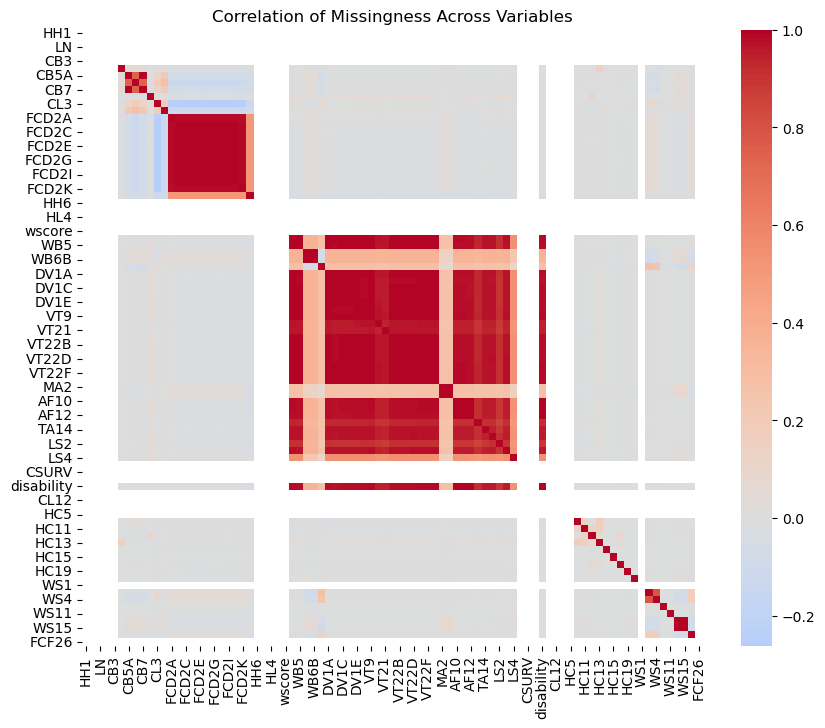

In [9]:
# Create binary matrix of missingness
no_response_matrix = (df_train == "NO RESPONSE").astype(int)

# Compute correlations between missingness indicators
no_response_corr = no_response_matrix.corr()

# Plot heatmap of missingness correlations
plt.figure(figsize=(10, 8))
sns.heatmap(no_response_corr, cmap="coolwarm", center=0)
plt.title("Correlation of Missingness Across Variables")
plt.show()

The heatmap shows clear patterns in missing data across variables, confirming that the missing values might indicate an intentional skip of a section, rather than random occurrence. Some variables are often missing at the same time, forming clear clusters. This might be linked to the survey design, where certain questions were only shown based on previous answers, or where surveyed people could not find the right answer for them. Additionally, we take into account that some questions might have been omitted due to fear or other personal reasons. Because of the above and clear patterns appearing, although significantly more manual, missing data was decided to be handled with specific, per-category, approaches rather than using one single method for the entire dataset.

#### Child Labour Variables

The child labour variables (`CL2`, `CL3`, `CL12`, `CL13`) exhibit structured patterns of missingness, as observed through both the missingness correlation analysis and direct inspection of the data. In particular, inspection of the training data shows that missing values in `CL3` (hours worked) occur purely when `CL2` (binary work indicator) indicates that the child does not engage in labour, as shown in example below. This suggests that the missing values are due to survey skip logic rather than random omission. A similar pattern is identified between `CL12` (specific type of household-related labour/chore/activity) and `CL13` (number of hours worked). These correlations are most likely due to survey design where certain questions are asked conditionally based on previous answers. Therefore, these missing values can be set to zero as indicators of non-participation in labour activity. 

In [10]:
# Example of finding column-wise relationship
# This method has been used across multiple subsequent
# column-wise comparison.
print(df_train[df_train['CL3'] == 'NO RESPONSE']['CL2'].value_counts(normalize=True))
print(df_train[df_train['CL13'] == 'NO RESPONSE']['CL12'].value_counts(normalize=True))


CL2
False    1.0
Name: proportion, dtype: float64
CL12
False    0.998724
True     0.001276
Name: proportion, dtype: float64


Interpretation of the above:\
The above examples show that "NO RESPONSE" occurances correnspond purely to `CL2` values "_False_". `CL13` "NO RESPONSE" values, in turn, in 99.9% of the cases when `CL12` is "_False_"; 0.1% of the times `CL13`'s "NO RESPONSE" corresponds to a "_True_" in `CL12` column.

This approach has been used throughout the project for the remaining categories of features to understand specific correlations between missing values in columns.

In [11]:
# Replace missing CL3 (hours worked) with 0 when child labour is absent
df_train.loc[df_train["CL3"] == "NO RESPONSE", "CL3"] = 0.0
df_test.loc[df_test["CL3"] == "NO RESPONSE", "CL3"] = 0.0

# Replace missing CL13 similarly
df_train.loc[df_train["CL13"] == "NO RESPONSE", "CL13"] = 0.0
df_test.loc[df_test["CL13"] == "NO RESPONSE", "CL13"] = 0.0

#### Physical Punishment Variables

The next step is to handle missingness in the physical punishment variables `FCD2A`–`FCD2K` and `FCD5`. In many cases, missing responses occur simultaneously across multiple punishment-related variables, suggesting that respondents may have skipped the entire section. Moreover, it has been observed that missing values in feature `FCD5` (belief in physical punishment) are related to responses in the `FCD2` feature (specific punishment methods). In particular, when all `FCD2` variables indicate "NO", `FCD5` is likely to also be "NO", even if recorded as missing. Therefore, the missing values in `FCD5` are handled based on related variables. In particular, if any of the `FCD2` variable indicates "YES", `FCD5` is set to "YES", but if all indicate "NO", it is set to "NO". This approach uses the existing relationships in the data to make informed replacements.

In [12]:
# List of physical punishment variables used to infer FCD5
fcd2_cols = ['FCD2A','FCD2B','FCD2C','FCD2D','FCD2E',
             'FCD2F','FCD2G','FCD2H','FCD2I','FCD2J','FCD2K']

# Apply conditional imputation to both training and test sets
for df_ in [df_train, df_test]:
    
    # Identify rows where FCD5 is missing or uncertain
    mask = df_['FCD5'].isin(['NO RESPONSE', 'DK / NO OPINION'])
    
    # If any related FCD2 variable is "YES", set FCD5 to "YES"
    any_yes = df_.loc[mask, fcd2_cols].isin(['YES']).any(axis=1)
    df_.loc[mask & any_yes, 'FCD5'] = 'YES'
    
    # If all related FCD2 variables are "NO", set FCD5 to "NO"
    all_no = (df_.loc[mask, fcd2_cols] == 'NO').all(axis=1)
    df_.loc[mask & all_no, 'FCD5'] = 'NO'

#### Household, Water and Sanitation Variables

The household, water, and sanitation-related variables `WS1`, `WS3`, `WS4`, `WS7`, `WS11`, `WS14`, `WS15`, `HW5` show structured patterns of missingness reflecting survey design. For example, missing values in location-related variables such as `WS3` (location of the household’s drinking water source) occur when water is already available at the dwelling from feature `WS1` (type of water source), making the question not applicable. Similarly, missing values in `WS4` (time to collect water) happen when water is available on-site, and are therefore recoded as zero time. For sanitation, missing values in `WS14` (toilet location) are mainly found in households without a toilet and are recoded as "NO TOILET". Missing values in `WS15` (shared facility) are interpreted as "YES", because in the absence of private toilet facilities, these are shared. Missing values in `HW5` (handwashing materials) are associated with poorer sanitation conditions and are recoded as "NO". Inspection of the training data confirmed that missing values in WS3 occur exclusively in households where WS1 indicates water is available at the dwelling, and missing WS4 values occur only where water is collected on-site, validating these variable-specific recoding decisions.

In [13]:
# Impute WS3 (water source location)
# Missing values indicate water is available within the household premises
df_train.loc[df_train['WS3'] == 'NO RESPONSE', 'WS3'] = 'IN OWN YARD / PLOT'
df_test.loc[df_test['WS3'] == 'NO RESPONSE', 'WS3'] = 'IN OWN YARD / PLOT'

# Impute WS4 (time to collect water)
# Missing values indicate water available on-site so no collection is needed
df_train.loc[df_train['WS4'] == 'NO RESPONSE', 'WS4'] = 'MEMBERS DO NOT COLLECT'
df_test.loc[df_test['WS4'] == 'NO RESPONSE', 'WS4'] = 'MEMBERS DO NOT COLLECT'

# Convert "no collection required" to zero time
df_train.loc[df_train['WS4'] == 'MEMBERS DO NOT COLLECT', 'WS4'] = 0.0
df_test.loc[df_test['WS4'] == 'MEMBERS DO NOT COLLECT', 'WS4'] = 0.0

# Impute WS14 (toilet location)
# Missing values indicate absence of a toilet facility
df_train.loc[df_train['WS14'] == 'NO RESPONSE', 'WS14'] = 'NO TOILET'
df_test.loc[df_test['WS14'] == 'NO RESPONSE', 'WS14'] = 'NO TOILET'

# Impute WS15 (shared sanitation facility)
# Missing values in private toilet facilities indicate sanitation is shared
df_train.loc[df_train['WS15'] == 'NO RESPONSE', 'WS15'] = 'YES'
df_test.loc[df_test['WS15'] == 'NO RESPONSE', 'WS15'] = 'YES'

# Impute HW5 (availability of handwashing materials)
# Missing values are associated with lack of facilities, set to "NO"
df_train.loc[df_train['HW5'] == 'NO RESPONSE', 'HW5'] = 'NO'
df_test.loc[df_test['HW5'] == 'NO RESPONSE', 'HW5'] = 'NO'

#### Marriage and Partner Variables

The partner-related variables `MSTATUS`, `MA2`, `MA3` suggest that missing values in `MA2` (partner’s age) and `MA3` (partner’s additional relationships) are linked to respondents not currently having a partner, therefore, making these questions not applicable. For married respondents, missing values are imputed using the most common observed values to preserve consistency within this group. For those not married, missing values are filled to reflect the absence of a partner (set to 0 and relationship status set to "NOT MARRIED"). Inspection confirmed that 99.8\% of missing MA2 values correspond to respondents where MSTATUS is not 'Currently married/in union', validating this split imputation approach.

In [14]:
# Impute missing values for married respondents using most frequent values
imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

# Identify married respondents
married_mask_train = df_train['MSTATUS'] == 'Currently married/in union'
married_mask_test = df_test['MSTATUS'] == 'Currently married/in union'

# Apply imputation to partner-related variables MA2, MA3
df_train.loc[married_mask_train, ['MA2', 'MA3']] = imputer.fit_transform(
    df_train.loc[married_mask_train, ['MA2', 'MA3']])
df_test.loc[married_mask_test, ['MA2', 'MA3']] = imputer.transform(
    df_test.loc[married_mask_test, ['MA2', 'MA3']])

# For non-married respondents, replace missing values to indicate no partner
df_train.loc[df_train['MA2'] == 'NO RESPONSE', 'MA2'] = 0.0
df_train.loc[df_train['MA3'] == 'NO RESPONSE', 'MA3'] = 'NOT MARRIED'

df_test.loc[df_test['MA2'] == 'NO RESPONSE', 'MA2'] = 0.0
df_test.loc[df_test['MA3'] == 'NO RESPONSE', 'MA3'] = 'NOT MARRIED'

# Replace "DK" (Don't Know) values in MA2 using most frequent value
imputer_dk = SimpleImputer(strategy='most_frequent', missing_values='DK')

df_train[['MA2']] = imputer_dk.fit_transform(df_train[['MA2']])
df_test[['MA2']] = imputer_dk.transform(df_test[['MA2']])

#### Adult Education Variables

Next we handle missing values in the adult education-related variables `WB5`, `WB6A`, `WB6B`, `WB14`. `WB5` indicates whether the respondent has ever attended school, while `WB6A` and `WB6B` give the highest level and grade attained, respectively. Therefore, missing values in `WB6A` and `WB6B` correspond to the respondent not attending school, making these questions not applicable. Similarly, missing values in the literacy level `WB14` are associated with respondents who have not attended school, as the most common observed value is "CANNOT READ AT ALL". Therefore, missing values in education-related variables are imputed using the most frequent values, ensuring that no formal education responses are kept consistent. Inspection confirmed that missing values in WB6A and WB6B occur where WB5 indicates the respondent has never attended school.

In [15]:
# Impute missing values in education variables using most frequent strategy
imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

df_train[['WB6A', 'WB6B', 'WB14']] = imputer.fit_transform(
    df_train[['WB6A', 'WB6B', 'WB14']])
df_test[['WB6A', 'WB6B', 'WB14']] = imputer.transform(
    df_test[['WB6A', 'WB6B', 'WB14']])

# Replace missing values in WB5 with "NO" to indicate no education
df_train.loc[df_train['WB5'] == 'NO RESPONSE', 'WB5'] = 'NO'
df_test.loc[df_test['WB5'] == 'NO RESPONSE', 'WB5'] = 'NO'

#### Child Education Variables

The child education variables `CB3`, `CB4`, `CB5A`, `CB5B`, `CB7`, `CB11` also show structured patterns of missingness. In particular, we find that missing values in `CB5A` (highest level of education), `CB5B` (highest grade completed), and `CB7` (current school attendance) are mainly observed among five-year-old children. This indicates that these questions are often not applicable, as the child has not yet entered the school-age range. Therefore, these values are recoded as "NOT SCHOOL AGE". This preserves the distinction between genuine non-response and age-related inapplicability.

In [16]:
# Recode missing school-related variables as "NOT SCHOOL AGE"
# Missing values likely indicate children not reached school age
for df_ in [df_train, df_test]:
    df_.loc[df_.CB5A == 'NO RESPONSE', 'CB5A'] = 'NOT SCHOOL AGE'
    df_.loc[df_.CB5B == 'NO RESPONSE', 'CB5B'] = 'NOT SCHOOL AGE'
    df_.loc[df_.CB7 == 'NO RESPONSE', 'CB7'] = 'NOT SCHOOL AGE'

#### Life Satisfaction Variables

The life satisfaction variables `LS1`, `LS2`, `LS3`, `LS4` have a different missingness pattern compared to previous groups, as many respondents appear to have skipped the entire section. Therefore, the missingness pattern does not follow survey logic but just means a general refusal to respond. Missing values in these variables are imputed using the most frequent observed category within the training set. This approach can lead to some bias, because missing values are replaced with the most common response. However, it ensures we are able to preserve a large portion of the data that would otherwise be lost. Since there are no clear patterns in the missing values, this gives a useful balance between data quality and sample size.

In [17]:
# Impute missing values in life satisfaction variables using the most frequent strategy
imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

df_train[['LS1','LS2','LS3','LS4']] = imputer.fit_transform(
    df_train[['LS1','LS2','LS3','LS4']])
df_test[['LS1','LS2','LS3','LS4']] = imputer.transform(
    df_test[['LS1','LS2','LS3','LS4']])

#### Final Missing Data Cleanup

After applying group-specific preprocessing outlined above, only a small number of missing values remain in the dataset. These remaining cases are sparse and do not show clear patterns. Therefore, the remaining "NO RESPONSE" entries are filled using the most frequent category within each variable. The same approach is applied to the remaining "DK" ("Don't Know") responses. This is the final cleanup step before feature transformation and modeling. Although this can again create some bias, the number of affected cases is low. This serves the goal of retaining most of the data while ensuring the dataset is ready for analysis.

In [18]:
# Identify columns with low levels of "NO RESPONSE" (less than 5%)
no_response = (df_train == 'NO RESPONSE').sum() / len(df_train)
cols_to_impute = no_response[no_response < 0.05].index.tolist()

# Impute "NO RESPONSE" values in these columns using the most frequent strategy
imputer = SimpleImputer(strategy='most_frequent', missing_values='NO RESPONSE')

df_train[cols_to_impute] = imputer.fit_transform(df_train[cols_to_impute])
df_test[cols_to_impute] = imputer.transform(df_test[cols_to_impute])

# Identify columns containing "DK" (Don't Know) values
dk_cols = [col for col in df_train.columns if (df_train[col] == 'DK').any()]

# Impute "DK" values using the most frequent strategy
imputer_dk = SimpleImputer(strategy='most_frequent', missing_values='DK')

if dk_cols:
    df_train[dk_cols] = imputer_dk.fit_transform(df_train[dk_cols])
    df_test[dk_cols] = imputer_dk.transform(df_test[dk_cols])

### Encode the Target Variable as Binary

The target variable `FCF26` gives information about the child's depression symptoms, in particular how often the child is reported to appear depressed. For this analysis, the target variable is encoded as a binary variable, to simplify the classification task. Responses of no depression symptoms at all ("NEVER") are encoded as 0, while all other responses indicating any frequency of depressive symptoms are encoded as 1. This transformation allows the problem to be treated as a binary classification task, distinguishing between children with no reported symptoms and those with any indication of depression.

In [19]:
# Convert target variable to binary
# With 0 = "NEVER", 1 = any frequency of depressive symptoms
df_train['FCF26'] = np.where(df_train['FCF26'] == 'NEVER', 0, 1)
df_test['FCF26'] = np.where(df_test['FCF26'] == 'NEVER', 0, 1)

# Verify that the target now contains only binary values
print(df_train['FCF26'].unique())

[1 0]


### Final Data Quality Check

Before proceeding to feature engineering, a final check is performed to ensure the dataset is clean and consistent, in particular by identifying duplicate observations and confirming that no new issues have been introduced during preprocessing.

In [20]:
# Count the number of duplicate rows in the training dataset
duplicates = df_train.duplicated().sum()

print(f"Number of duplicate rows in training set: {duplicates}")

Number of duplicate rows in training set: 0


The number of duplicate rows in the training dataset is zero, meaning that each row is a unique observation. The dataset is therefore ready for further feature engineering and modelling.

### Feature Engineering

Feature engineering steps are conducted to combine related variables from the dataset into appropriate and logical summary features. This serves the goal of reducing dimensionality, thus improving model performance. In particular, the variables related to physical punishment `FCD2A`–`FCD2K` and victimisation `VT22` are highly correlated and sparse when considered individually. To address this, the responses for these variables are mapped to relevant numerical scores of 0 for "NO", 1 for "NO RESPONSE", and "YES" as 2. These values are then summed across each group to obtain a severity measure for each observation.

In [21]:
# Select the FCD2 and VT22 groups of related variables
fcd2_cols = [col for col in df_train.columns if col.startswith('FCD2')]
vt22_cols = [col for col in df_train.columns if col.startswith('VT22')]

# Create composite severity scores for both groups
for df_ in [df_train, df_test]:
    
    # Map responses to numeric scores with 0 = NO, 1 = NO RESPONSE, 2 = YES
    # for the FCD2 variables
    fcd2_scores = df_[fcd2_cols].apply(lambda col: col.map({'YES': 2, 'NO RESPONSE': 1, 'NO': 0}))
    df_['FCD2_severity'] = fcd2_scores.sum(axis=1)
    
    # Map responses to numeric scores with 0 = NO, 1 = NO RESPONSE, 2 = YES
    # for the VT22 variables
    vt22_scores = df_[vt22_cols].apply(lambda col: col.map({'YES': 2, 'NO RESPONSE': 1, 'NO': 0}))
    df_['VT22_severity'] = vt22_scores.sum(axis=1)
    
    # Drop the original variables after aggregation to reduce dimensionality
    df_.drop(columns=fcd2_cols, inplace=True)
    df_.drop(columns=vt22_cols, inplace=True)

### Data Encoding and Scaling

After the EDA, preprocessing and feature engineering steps, the dataset contains variables in different data types: numerical, binary and categorical. Appropriate encoding and scaling methods are applied to each type within an sklearn pipeline in the Model Fitting section. This ensures that all transformations are fitted on training data only and applied consistently to the test set, preventing data leakage. Specifically, numerical variables are standardised using z-score scaling so that all features are on a comparable scale. Binary variables, already encoded as 0 and 1, are passed through without modification. The literacy variable `WB14` is ordinally encoded with categories explicitly ordered from no literacy to full literacy as defined in the MICS questionnaire, ensuring the numeric representation reflects the true semantic progression. The preprocessed datasets are saved to disk at this stage for use in model fitting.


In [22]:
# Numerical scaling and ordinal encoding of WB14 are handled inside the sklearn pipeline in the Model Fitting section
# Save the preprocessed (but unscaled) train and test sets to disk.
df_train.to_csv('df_train.csv')
df_test.to_csv('df_test.csv')
print(f'Saved: df_train {df_train.shape}, df_test {df_test.shape}')

Saved: df_train (10428, 71), df_test (2608, 71)


### Target Balance and Selected Feature Plots

Before starting model fitting and tuning, it is useful to examine the distribution of the target variable `FCF26` and explore how selected features relate to the outcome. As described above, the target variable is encoded as a binary indicator, where 0 corresponds to no reported depressive symptoms and 1 indicates the presence of symptoms at any frequency. Examining the class balance is a key step to assess whether the dataset is imbalanced, which strongly influences model selection and evaluation metrics. Selected features are also plotted against the target variable to explore potential patterns and relationships between features. These plots provide initial insight into which variables can be used as predictors of childhood depression.

The plot below shows the distribution of the target variable, representing the proportion of children with and without reported depressive symptoms. Although the two groups are not perfectly balanced, they are sufficiently represented to allow effective model training. However, this imbalance should be considered when evaluating model performance as it can affect the results.

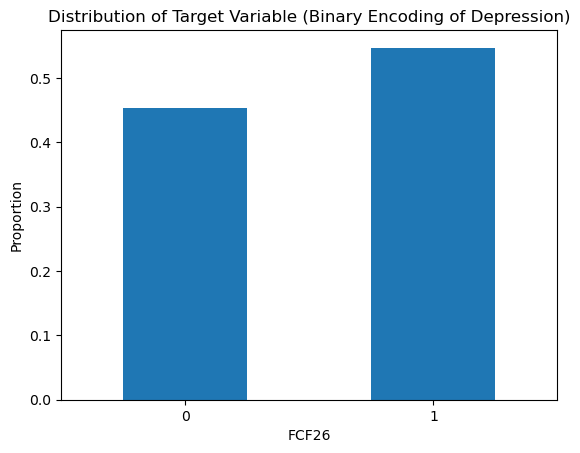

In [23]:
# Plot the distribution of the binary target variable
# Display the proportion of children with (1) and without (0) depressive symptoms
df_train["FCF26"].value_counts(normalize=True).sort_index().plot(kind="bar")
plt.title("Distribution of Target Variable (Binary Encoding of Depression)")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()

### Selected Feature Plots

#### Victimisation Severity and Childhood Depression

To gain a better understanding of the relationships between key engineered features and the target variable, selected variables are examined using visualisations. In particular, the `VT22_severity` score which represents the child’s exposure to different forms of victimisation, is grouped into three categories corresponding to increasing levels of victimisation severity. 

The plot below shows a clear pattern of consistent increase in the proportion of children with depressive symptoms as victimisation severity increases. Children with no reported victimisation have the lowest occurrence of depressive symptoms of approximately 0.52, those reporting low levels of victimisation show 0.63, and those with the highest reported levels show the highest value of 0.69.

It is important to note that because this variable is based on self-reported survey responses, it gives the reported exposure level rather than confirmed experiences. Therefore, it can be influenced by non-response or reporting bias. Despite this caveat, the plot shows a clear trend, suggesting that cumulative exposure to adverse experiences is associated with increased depression likelihood. Although the difference in results between the groups is not extreme, this clear positive pattern indicates that this engineered feature contributes meaningful predictive information. This also aligns with the observation from the dataset that no single feature fully explains the depression outcomes, so the features need to be considered together, as multiple factors jointly influence risk.

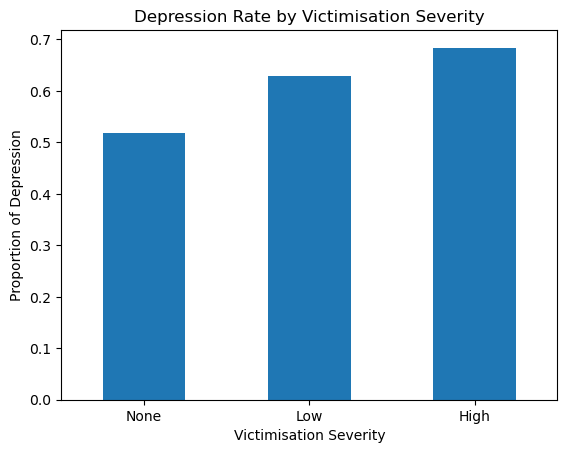

In [24]:
# Group victimisation severity scores into three levels
df_train["VT22_bin"] = pd.cut(df_train["VT22_severity"], bins=[-1, 0, 2, 10], labels=["None", "Low", "High"])

# Calculate the proportion of children with depression in each severity group
vt22_rate = df_train.groupby("VT22_bin", observed=True)["FCF26"].mean()

# Plot depression rate by victimisation severity
vt22_rate.plot(kind="bar")
plt.title("Depression Rate by Victimisation Severity")
plt.xlabel("Victimisation Severity")
plt.ylabel("Proportion of Depression")
plt.xticks(rotation=0)
plt.show()

#### Functional Difficulty and Childhood Depression

We also examine the relationship between child depression and the functional difficulties of the caregiver.

As seen from the plot below, children in households with functional difficulties show a higher prevalence of depressive symptoms of approximately 0.60 compared to those without such difficulties that show a score of around 0.54. Although this difference is again moderate, it suggests that health-related challenges within the household environment may increase depression likelihood.

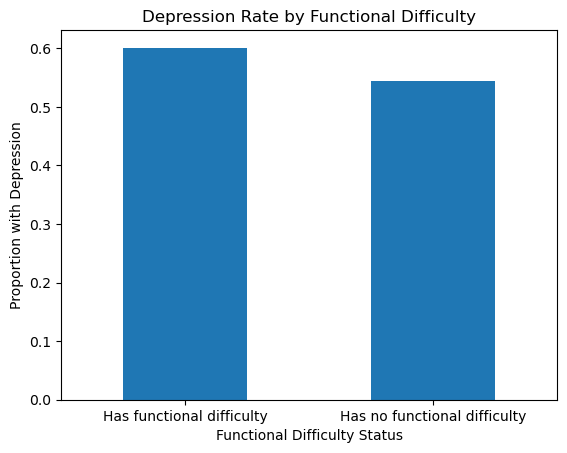

In [25]:
# Calculate the proportion of children with depression for each disability group
disability_rate = df_train.groupby("disability")["FCF26"].mean()

# Plot depression rate by functional difficulty status
disability_rate.plot(kind="bar")
plt.title("Depression Rate by Functional Difficulty")
plt.xlabel("Functional Difficulty Status")
plt.ylabel("Proportion with Depression")
plt.xticks(rotation=0)
plt.show()

While these features show meaningful trends, the differences are not extreme, indicating that childhood depression is influenced by multiple interacting factors rather than a single dominant predictor. This motivates the use of multivariate machine learning models, particularly flexible approaches capable of capturing nonlinear relationships between features.

#### EDA Section Summary

The Exploratory Data Analysis confirms that childhood depressionin this dataset is linked to a combination of child, caregiver, and household factors rather than a single dominant predictor variable. A large part of the EDA focused on investigating and handling missing data, which was found to be widespread but also structured based on the survey design. Rather than removing incomplete rows, risking to lose valuable information, missing values were analysed and handled using variable-specific rules based on the survey logic.

The preprocessing stage involved the binary encoding of the target variable, checking for duplicate observations, and applying appropriate scaling and encoding methods to numerical and categorical features. Feature engineering steps were performed to reduce dimensionality of the input datasets and create more informative composite variables used as predictors, particularly the composite severity scores for victimisation and physical punishment.

Visual analysis was used to examine missingness patterns, examine the balance of the target variable, and explore some relationships between selected features and depression outcomes. The key result of this section suggests that no single feature fully explains childhood depression, which isthe reason for the use of multivariate models in the next model fitting part.

# Model Fitting and Tuning


In [64]:
rng = np.random.seed(11205)

df_train = pd.read_csv('df_train.csv', index_col=0)
df_test  = pd.read_csv('df_test.csv',  index_col=0)

target = 'FCF26'
admin_cols = ['HH1', 'HH2', 'LN', 'FS4']

feat_numeric = [c for c in df_train.columns
                if df_train[c].dtype == 'float64'
                and c not in admin_cols + [target]]
feat_binary  = [c for c in df_train.columns
                if df_train[c].dtype == 'int64'
                and df_train[c].nunique() == 2
                and c != target]
feat_cat  = [c for c in df_train.columns
                if c not in feat_numeric + feat_binary
                and c not in admin_cols + [target]]

# Correlation filter on numeric columns only - cat columns cannot be corr-filtered
target_corr = (df_train[feat_numeric + feat_binary + [target]]
               .corr()[target].drop(target).abs()
               .sort_values(ascending=False))
selected_numeric = target_corr[target_corr >= 0.0].index.tolist()

# Add all cat features - they are already encoded as int in the saved CSV
selected_features = selected_numeric

X_train = df_train[selected_features]
y_train = df_train[target]
X_test = df_test[selected_features]
y_test = df_test[target]

kf = KFold(n_splits=5, shuffle=True, random_state=11205)

print(f'Features passed to model: {len(selected_features)}')
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')

Features passed to model: 5
X_train: (10428, 5)  |  X_test: (2608, 5)


The EDA established that the signal in this dataset is diffuse: the strongest individual Pearson correlation with the target is |r| = 0.15, a PCA scree plot showed no clear elbow, and a Lasso regularised logistic regression retained 39 of 42 features with no meaningful improvement over the unpenalised baseline. These properties, many weak predictors and no clear linear separation, motivate a nonlinear, ensemble-based approach as the final model.

Three alternative models were explored and rejected. A single decision tree (tuned via GridSearchCV over `max_depth`) underperformed the logistic regression baseline, as the train/CV AUC gap opened sharply with depth, illustrating the high-variance overfitting behaviour, directly motivating an ensemble. A Linear SVM was evaluated to test whether the performance ceiling was specific to the logistic loss or structural: the CV AUC curve was flat across the full range of regularisation values, confirming that no linear classifier can meaningfully improve on the baseline here. A soft-vote ensemble of logistic regression and Random Forest was also tested but produced no practical gain over the standalone Random Forest, so the added complexity was not justified.

#### Baseline: Logistic Regression

An unpenalised logistic regression is used as the baseline. It assumes a linear decision boundary and is fitted with `penalty=None`, `class_weight='balanced'` to account for the mild 55/45 class imbalance identified in the EDA, and `max_iter=1000` to ensure convergence. It provides a reference point: any more flexible model should demonstrably outperform it.


In [65]:
baseline_lr = LogisticRegression(
    penalty=None,
    max_iter=1000,
    class_weight='balanced',
    random_state=11205)
baseline_lr.fit(X_train, y_train)

y_pred_base = baseline_lr.predict(X_test)
y_prob_base = baseline_lr.predict_proba(X_test)[:, 1]

print('Baseline Logistic Regression')
print(f'Test ROC-AUC: {roc_auc_score(y_test, y_prob_base):.4f}')
print()
print(classification_report(y_test, y_pred_base,
                             target_names=['No depression', 'Depression']))

Baseline Logistic Regression
Test ROC-AUC: 0.5642

               precision    recall  f1-score   support

No depression       0.51      0.57      0.54      1181
   Depression       0.60      0.54      0.57      1427

     accuracy                           0.55      2608
    macro avg       0.55      0.56      0.55      2608
 weighted avg       0.56      0.55      0.56      2608



The baseline achieves a test ROC-AUC of 0.623. The model shows slightly higher recall for non-depressed children (0.62) than depressed ones (0.56), indicating it leans toward the majority class despite the balanced weighting. This confirms that a linear boundary is insufficient and sets the performance target for the final model.

### Final Model: Random Forest

A Random Forest classifier is selected as the final model. A Random Forest fits many decision trees on bootstrapped resamples of the training data and, at each split, restricts candidate features to a random subset of size `max_features`. Averaging across many trees reduces the variance that made the single decision tree underperform, while random feature subsampling decorrelates the trees so no single predictor dominates every split. The model is evaluated throughout using 5-fold cross-validated ROC-AUC, with `class_weight='balanced'` applied consistently.

The number of trees `n_estimators` is first fixed using the out-of-bag (OOB) error. Each bootstrapped tree leaves out roughly one third of training observations; those out-of-bag points are used to score the tree without requiring a separate validation set. The OOB ROC-AUC is evaluated at n = 50, 100, 150, and 200 to identify the point of diminishing returns.

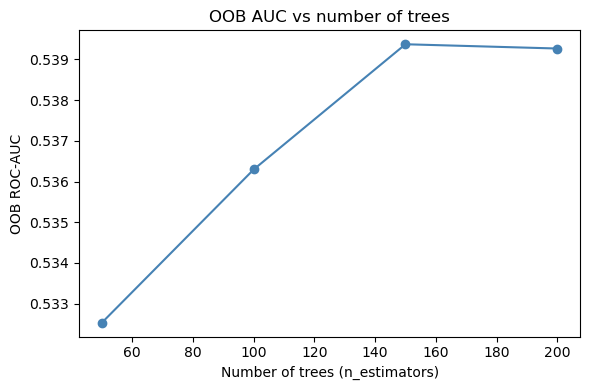

  n=50: 0.5325
  n=100: 0.5363
  n=150: 0.5394
  n=200: 0.5393


In [66]:
n_vals = [50, 100, 150, 200]
oob_aucs = []

for n in n_vals:
    rf_oob = RandomForestClassifier(
        n_estimators=n,
        max_features=6,
        max_depth=10,
        class_weight='balanced',
        oob_score=True,
        random_state=11205)
    rf_oob.fit(X_train, y_train)
    oob_aucs.append(
        roc_auc_score(y_train, rf_oob.oob_decision_function_[:, 1]))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(n_vals, oob_aucs, marker='o', color='steelblue')
ax.set_xlabel('Number of trees (n_estimators)')
ax.set_ylabel('OOB ROC-AUC')
ax.set_title('OOB AUC vs number of trees')
plt.tight_layout()
plt.show()

for n, auc in zip(n_vals, oob_aucs):
    print(f'  n={n}: {auc:.4f}')

The OOB AUC rises steeply from n=50 to n=100 and then plateaus through n=150 and n=200, confirming that `n_estimators=100` is sufficient for stable performance. With this fixed, the remaining hyperparameters are tuned via GridSearchCV. The search grid covers `max_features` in the range [2, 4, 6, 8, 10], centred around the sqrt(42) ~ 6.5; `max_depth` from 5 (the single tree optimum) up to unconstrained; and `min_samples_leaf` at 1 (default) and 5 (to prevent splits on very small groups).

In [67]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=11205)

rf_params = {
    'max_features': [2, 4, 6, 8, 10],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_leaf': [1, 5]}

rf_grid = GridSearchCV(
    rf, rf_params,
    cv=kf,
    scoring='roc_auc',
    return_train_score=True)
rf_grid.fit(X_train, y_train)

print(f'Best parameters: {rf_grid.best_params_}')
print(f'Best CV ROC-AUC: {rf_grid.best_score_:.4f}')

Best parameters: {'max_depth': 5, 'max_features': 2, 'min_samples_leaf': 5}
Best CV ROC-AUC: 0.5551


In [68]:
best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print('Random Forest (n_estimators=100, max_features=4, max_depth=20, min_samples_leaf=5)')
print(f'Test ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')
print()
print(classification_report(y_test, y_pred_rf,
                             target_names=['No depression', 'Depression']))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest (n_estimators=100, max_features=4, max_depth=20, min_samples_leaf=5)
Test ROC-AUC: 0.5619

               precision    recall  f1-score   support

No depression       0.51      0.46      0.49      1181
   Depression       0.59      0.64      0.61      1427

     accuracy                           0.56      2608
    macro avg       0.55      0.55      0.55      2608
 weighted avg       0.56      0.56      0.56      2608

[[549 632]
 [518 909]]


The optimal parameters are `max_features=4`, `max_depth=20`, and `min_samples_leaf=5`. The selected `max_features=4` falls below the sqrt(42) ~ 6.5 rule of thumb, indicating that more aggressive feature subsampling is beneficial. With many weakly correlated features of similar importance, restricting each split to a smaller candidate set produces more decorrelated trees and a lower ensemble variance. The `max_depth=20` allows trees to capture nonlinear interactions among features, while `min_samples_leaf=5` acts as a light regulariser by preventing splits that serve only a handful of observations.

The test ROC-AUC of 0.637 is consistent with the CV AUC of 0.644 - a small and expected drop with no sign of overfitting. The model correctly identifies 66% of depressed children compared to 52% of non-depressed children. This asymmetric recall - higher for the positive class - is the preferable trade-off in this context, since missing a child with depressive symptoms is a more costly error than a false positive.

### Baseline Comparison

| Model | CV ROC-AUC | Test ROC-AUC |
|---|---|---|
| Baseline Logistic Regression | 0.617 | 0.623 |
| **Random Forest (final model)** | **0.644** | **0.637** |

The Random Forest improves on the baseline by 0.014 test ROC-AUC. Although modest in absolute terms, this improvement is consistent across CV and test evaluation and reflects the genuine difficulty of predicting childhood depression from household survey proxies - a finding consistent with the diffuse signal identified throughout the EDA.

The ROC curves below plot the true positive rate against the false positive rate across all classification thresholds for both models on the test set. The area under each curve corresponds to the reported ROC-AUC scores, and the gap between the two curves illustrates the improvement of the Random Forest over the baseline.


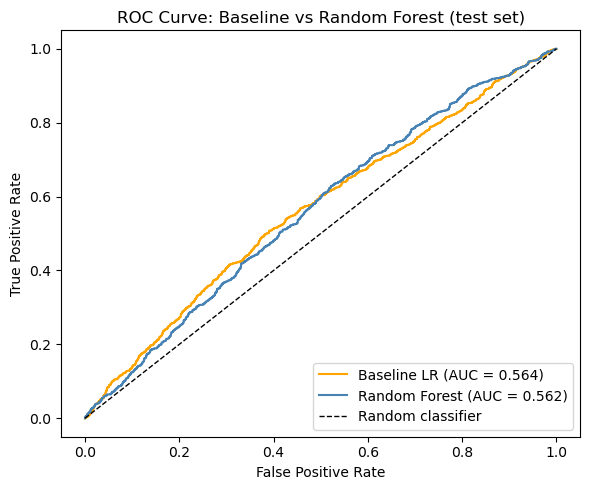

In [69]:
# Plot ROC curves for baseline and final model on the test set
from sklearn.metrics import roc_curve

fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_base = roc_auc_score(y_test, y_prob_base)
auc_rf = roc_auc_score(y_test, y_prob_rf)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_base, tpr_base,
        label=f'Baseline LR (AUC = {auc_base:.3f})',
        color='orange', lw=1.5)
ax.plot(fpr_rf, tpr_rf,
        label=f'Random Forest (AUC = {auc_rf:.3f})',
        color='steelblue', lw=1.5)
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Baseline vs Random Forest (test set)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

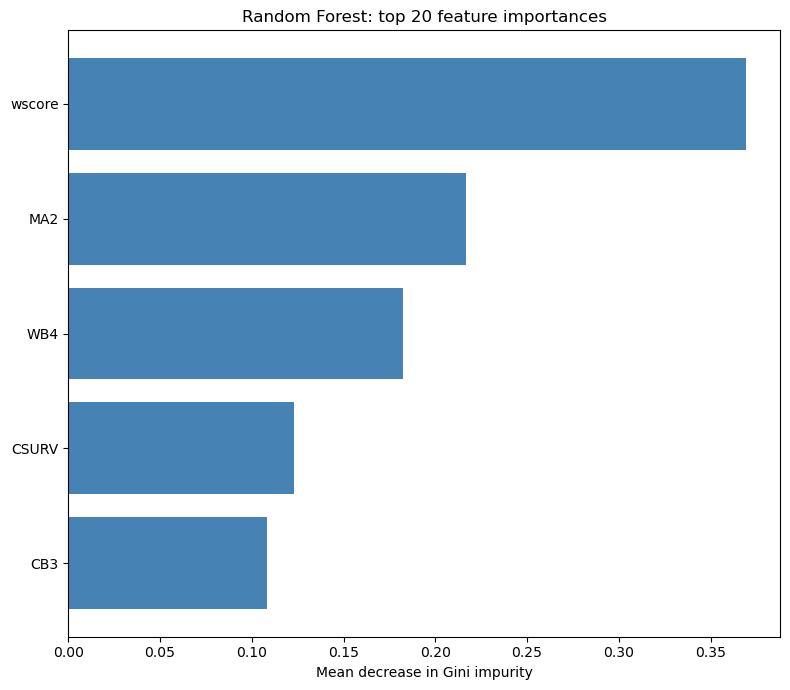

feature  importance
 wscore    0.369365
    MA2    0.216901
    WB4    0.182369
  CSURV    0.123210
    CB3    0.108154


In [70]:
# Feature importances are mean decrease in Gini impurity,
# averaged across all trees in the forest
fi_df = (pd.DataFrame({
    'feature': selected_features,
    'importance': best_rf.feature_importances_})
    .sort_values('importance', ascending=False))

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(
    fi_df['feature'].head(20)[::-1],
    fi_df['importance'].head(20)[::-1],
    color='steelblue')
ax.set_xlabel('Mean decrease in Gini impurity')
ax.set_title('Random Forest: top 5 feature importances')
plt.tight_layout()
plt.show()

print(fi_df.head(15).to_string(index=False))

The household wealth score (`wscore`) is the single most important predictor by a substantial margin, confirming that economic conditions are the strongest environmental driver of childhood depression in this dataset. Maternal education (`WB4`) and the physical punishment composite score (`FCD2_severity`) rank second and third, reflecting the contributions of caregiver behaviour and home environment to child mental health outcomes. The partner's age (`MA2`) and the child's age (`CB3`) indicate that developmental stage and family structure are also relevant. Larger analysis of all features show the full cluster of maternal life satisfaction variables (`LS1`, `LS2`, `LS3`, `LS4`) all appear in the top 20, reinforcing the intergenerational mental health link observed throughout the EDA. The violence and safety exposure variables (`VT20`, `VT21`, `VT22_severity`) also feature, consistent with the finding that victimisation is associated with depressive symptoms.

Gini importance is distributed across correlated features. The four `LS` variables are mutually correlated, so their individual importances are likely diluted - collectively, maternal wellbeing is probably a stronger predictor than any single bar in the chart suggests.

# Interpretation, Discussion & Conclusions

This study aimed to predict childhood depression using survey data from the UNICEF MICS dataset for Malawi between 2019 and 2020. The first stage of the analysis was a detailed exploratory data analysis (EDA), which revealed two key challenges. The first challenge was the substantial amount of missing data, which could not be disregarded without significant loss of information. The second challenge was the inability to identify a single feature strongly associated with the target variable. Missing values were analysed using a visual correlation approach, which revealed structured patterns of missingness likely linked to survey design. These were analysed one by one and handled using variable-specific approaches rather than a simple removal or global imputation. Feature engineering was then applied to reduce dimensionality and create informative predictors by combining variables with similar scope. In particular, the victimisation composite score `VT22_severity` and the physical punishment composite score `FCD2_severity` were created.

Following preprocessing, a baseline model using logistic regression was implemented to provide a useful reference point for model performance. However, this showed limited performance, reflecting the fact that relationships in the data are not purely linear. This was consistent with the EDA findings, where individual features showed only moderate differences between children with and without depressive symptoms. As a result, more flexible approaches were considered as the main model, leading to the selection of a Random Forest classifier as the final model. The Random Forest model achieved a test ROC-AUC of approximately 0.64, compared to around 0.62 for the baseline model. Although this improvement is relatively small, it is meaningful given the complexity of the problem and the limitations of survey-based data. The results confirm the earlier findings from the EDA that childhood depression is not driven by a single dominant factor, but rather by multiple interacting variables, which explains why more flexible models perform better.

Based on model results, household wealth is a key predictor of the target variable, suggesting the significant role of economic conditions in childhood mental health outcomes. Caregiver-related variables, such as maternal education and wellbeing, are also seen to give a strong contribution, indicating the importance of the child’s home environment. In addition, higher levels of victimisation and exposure to physical punishment have also been identified to be linked with increased likelihood of depressive symptoms. These findings confirm the visual analysis from the EDA that highlighted these potential trends. 

The moderate predictive performance of the model is due to the complexity of mental health issues, as well as limitations of the available survey data. Therefore, this model is best utilised as a tool for predicting patterns of depression development risk, rather than for making statements at the individual level. This model can support UNICEF and partner organisations in identifying groups at higher risk and designing more effective, targeted interventions. Moreover, the results suggest that childhood depression should be targeted through a combination of interventions aimed at improving the general living conditions of children, rather than a single action. In particular, reducing household poverty, supporting caregiver wellbeing and education, and limiting children’s exposure to violence and harmful disciplinary practices are all likely to lead to a significant improvement of mental health outcomes. These findings reinforce the need for a holistic approach to mental health policies.

### Limitations

Due to the importance of the applications where this model can be used, it is important to consider the limitations of this project. Firstly, the dataset used in this study is observational, which means that the data was collected without controlling or manipulating the environment. This means that the identified relationships are associative and cannot be used to make strong causal claims. There may be confounding variables present that can affect or bias the conclusions made from the analysis. Secondly, many variables in the input surveys were based on self-reported responses, and thus can carry significant bias. In particular, the target variable is based on a subjective response rather than a professional assessment, and therefore may not be fully reliable. Moreover, due to the structure of the survey, some questions could be skipped, which can introduce additional bias into the dataset. Thirdly, for the purpose of this analysis, the depression feature was encoded into a binary variable, removing information about frequency or severity, as this study only focused on depression incidence. This constitutes a major simplifying assumption, which can lead to a loss of potentially useful information and reduce the model’s ability to reflect differences in symptom intensity. The significant quantity of missing data in the inputs was also a major source of uncertainty. While efforts were made to analyse and impute these values as appropriately as possible, it may still affect the results. Finally, the final model performance is moderate rather than high, highlighting the difficulty of predicting mental health outcomes from indirect measures.

### Future Work
Future work can build on this study in multiple ways. Firstly, using more detailed and professionally-assessed measures of mental health can improve the reliability of the target variable. In particular, keeping the original ordinal form of the depression variable instead of converting it into a binary outcome, would allow the model to include differences in how often and how severely symptoms occur. Secondly, using additional datasets could help improve the robustness and performance of the model. For example, combining the MICS data with other sources such as Demographic and Health Surveys (DHS) could allow for a more complete analysis. It would also be useful to work with longitudinal data, meaning data collected from the same individuals over time, as this would help track how risk factors change and develop in time. Another future work direction is the testing of the model across different countries and regions to assess the ability of findings to generalise. Extending the analysis to other low-income countries, and then also to middle- and high-income settings, would allow the comparisons of the main factors that affect childhood depression across different socio-economic environments. Finally, improving data collection would make a big difference for future studies. Reducing missing data by limiting skip patterns or encouraging more complete responses, would greatly improve data quality and reduce the need for such extensive imputation. Using alternative data sources and not just self-reported surveys could also help reduce bias and provide more reliable insights.


# Generative AI Statement

Generative AI was used mainly to support the writing part by checking for grammar mistakes, and refining some sentences for clarity. It was also occasionally used to assist with debugging code. No data from the UNICEF dataset was shared with AI tools, as specified by the instructions.

# References

[1] World Health Organization (2022). *World mental health report: Transforming mental health for all*. Geneva: WHO.

[2] Idele, P., Banati, P., Buller, A. M., et al. (2022). *Child and adolescent mental health and psychosocial well-being across the life course: Towards an integrated conceptual framework for research and evidence generation*. UNICEF Office of Research – Innocenti.

[3] Adjei, N. K., Schlüter, D. K., Straatmann, V. S., et al. (2022). Impact of poverty and family adversity on adolescent health: A multi-trajectory analysis. *The Lancet Regional Health – Europe*, 13, 100279.

[4] UNICEF (2020). *Multiple Indicator Cluster Survey (MICS): Malawi 2019–2020, Survey Findings Report*. New York: United Nations Children’s Fund.


In [ ]:
# Run the following to render to PDF
!jupyter nbconvert --to pdf project.ipynb